## Data Loading
Here we load the data and take a look at the first few rows of the data.

In [2]:
import pandas as pd

# Load the behaviors.tsv file
behaviors_header = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_df = pd.read_csv('./behaviors.tsv', sep='\t', names=behaviors_header)
print(len(behaviors_df))
behaviors_df.head()


156965


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


## Preprocessing
Now we need to transmute the data in order to fit the model:

In [3]:
# Remove duplicates based on impression_id
behaviors_df = behaviors_df.drop_duplicates(subset='impression_id')

# Remove duplicates based on the combination of user_id and time
behaviors_df = behaviors_df.drop_duplicates(subset=['user_id', 'time'])

# Remove rows with missing values
behaviors_df = behaviors_df.dropna()

# The 'impressions' column contains a list of items with suffix 0 or 1 to indicate clicks.
# We turn them into tuples of (item, click) and store them over the original column.
behaviors_df['impressions'] = behaviors_df['impressions'].apply(lambda x: [(i[:-2], int(i[-1])) for i in x.split()])
behaviors_df['history'] = behaviors_df['history'].apply(lambda x: [i for i in x.split()])


# Print length of the cleaned dataframe
print(len(behaviors_df))

# Display the first few rows of the cleaned dataframe
behaviors_df.head()


153710


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,"[N55189, N42782, N34694, N45794, N18445, N6330...","[(N55689, 1), (N35729, 0)]"
1,2,U91836,11/12/2019 6:11:30 PM,"[N31739, N6072, N63045, N23979, N35656, N43353...","[(N20678, 0), (N39317, 0), (N58114, 0), (N2049..."
2,3,U73700,11/14/2019 7:01:48 AM,"[N10732, N25792, N7563, N21087, N41087, N5445,...","[(N50014, 0), (N23877, 0), (N35389, 0), (N4971..."
3,4,U34670,11/11/2019 5:28:05 AM,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[(N35729, 0), (N33632, 0), (N49685, 1), (N2758..."
4,5,U8125,11/12/2019 4:11:21 PM,"[N10078, N56514, N14904, N33740]","[(N39985, 0), (N36050, 0), (N16096, 0), (N8400..."


## Interaction Matrix
We need to create an interaction matrix between the users and the items. This matrix will be used to train the model.


The active selection of code is creating an interaction matrix from a DataFrame called behaviors_df. This matrix represents user interactions with various items, which is a common task in collaborative filtering for recommendation systems.

First, the code uses the explode method on the behaviors_df DataFrame to transform each element of the 'impressions' column, which is assumed to be a list-like structure, into separate rows. This effectively flattens the lists in the 'impressions' column so that each impression gets its own row, while replicating the corresponding 'user_id' values.

Next, the pivot method is used to reshape the DataFrame. The pivot method creates a new DataFrame where the index is 'user_id', the columns are the unique values from the 'impressions' column, and the values are the 'impressions' themselves. This results in a matrix where each row represents a user, each column represents an item, and the cells indicate whether the user has interacted with the item.

The notna method is then applied to the pivoted DataFrame to convert the presence of an interaction (non-null values) into True and the absence of an interaction (null values) into False. The astype(int) method converts these boolean values into integers (1 for True and 0 for False), creating a binary interaction matrix.

The fillna(0) method is used to ensure that any remaining null values are replaced with 0, which might be necessary if there were any missing data points. Finally, the head method is called to display the first few rows of the interaction matrix, and the print function outputs the shape of the matrix, indicating its dimensions.

This code effectively transforms the original DataFrame into a format suitable for collaborative filtering algorithms by creating a binary interaction matrix that can be used to analyze user-item interactions.

In [4]:
'''# Explode the 'impressions' column and drop duplicates
exploded_df = behaviors_df.explode('impressions').drop_duplicates(subset=['user_id', 'impressions'])

# Pivot the DataFrame to create the interaction matrix
interaction_matrix = exploded_df.pivot(index='user_id', columns='impressions', values='impressions').notna().astype(int)

# Fill any remaining NaN values with 0
interaction_matrix = interaction_matrix.fillna(0)

# Print the shape of the interaction matrix
print(interaction_matrix.shape)

# Display the first few rows of the interaction matrix
interaction_matrix.head()
'''
# Extract article IDs and click values from the impressions column
user_ids = []
article_ids = []
click_values = []

for _, row in behaviors_df.iterrows():
    user = row['user_id']
    for impression in row['impressions']:
        article_id = impression[0]  # Extract just the article ID
        click_value = impression[1]  # Extract the click value (0 or 1)
        user_ids.append(user)
        article_ids.append(article_id)
        click_values.append(click_value)

# Create a DataFrame with the extracted values
interaction_df = pd.DataFrame({
    'user_id': user_ids,
    'article_id': article_ids,
    'click': click_values
})

# If there are duplicates, keep the maximum value (prioritize clicks)
interaction_df = interaction_df.groupby(['user_id', 'article_id'])['click'].max().reset_index()

# Create the interaction matrix using pivot
interaction_matrix = interaction_df.pivot(
    index='user_id', 
    columns='article_id',
    values='click'
).fillna(0)

# Print the shape of the new interaction matrix
print("New interaction matrix shape:", interaction_matrix.shape)


# can we sort by the most clicked articles?
# Sort the articles by the number of clicks
sorted_articles = interaction_matrix.sum().sort_values(ascending=False)
# pretty print the top 10 articles
print("Top 10 articles:")
print(sorted_articles.head(10))

# Display the first few rows of the interaction matrix
interaction_matrix.head()



New interaction matrix shape: (49108, 20252)
Top 10 articles:
article_id
N55689    4189.0
N35729    3227.0
N33619    3149.0
N53585    2772.0
N63970    2492.0
N49685    2227.0
N49279    2200.0
N287      2057.0
N23446    1865.0
N51048    1818.0
dtype: float64


article_id,N10005,N10007,N10010,N10011,N10015,N10022,N10023,N10026,N1003,N10031,...,N9982,N9983,N9986,N9989,N999,N9991,N9994,N9997,N9998,N9999
user_id,,,,,,,,,,,,,,,,,,,,,
U100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U10001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U10003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U10008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Model Training
Now we need to train the model using the interaction matrix. We will use cosine similarity to find what articles should be recommended to the user, based on the articles they have interacted with, as well as other users' interactions. Assuming we now have a binary interaction matrix, we can use cosine similarity to find the similarity between users or items.

In [5]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Convert to sparse matrix for efficiency
interaction_sparse = csr_matrix(interaction_matrix.values)

# For item-item similarity:
item_similarity = cosine_similarity(interaction_sparse.T)
item_similarity_df = pd.DataFrame(
    item_similarity, 
    index=interaction_matrix.columns, 
    columns=interaction_matrix.columns
)

# For user-user similarity (if needed):
user_similarity = cosine_similarity(interaction_sparse)
user_similarity_df = pd.DataFrame(
    user_similarity, 
    index=interaction_matrix.index, 
    columns=interaction_matrix.index
)

# Check shapes
print("Item similarity matrix shape:", item_similarity_df.shape)
print("User similarity matrix shape:", user_similarity_df.shape)

# Display a sample of the item similarity matrix
item_similarity_df.iloc[:5, :5]

# Check that the function actually managed to calculate the similarity between items, we need positive values and not 0
print("Min item similarity:", item_similarity_df.min().min())
print("Max item similarity:", item_similarity_df.max().max())


Item similarity matrix shape: (20252, 20252)
User similarity matrix shape: (49108, 49108)
Min item similarity: 0.0
Max item similarity: 1.0000000000000446


Now that we have an item-item matrix, we can use it to recommend items to users. We will use the item-item matrix to find the most similar items to the ones the user has interacted with, and recommend those items to the user.

In [6]:
from random import randint


def recommend_articles(user_id, interaction_matrix, item_similarity_df, n=10):
    """
    Generate article recommendations for a specific user using item-based collaborative filtering
    
    Args:
        user_id: The ID of the user to generate recommendations for
        interaction_matrix: The user-item interaction matrix
        item_similarity_df: Item-item similarity matrix
        n: Number of recommendations to generate
        
    Returns:
        List of recommended article IDs
    """
    # Check if user exists in the interaction matrix
    if user_id not in interaction_matrix.index:
        return [], {}
    
    # Get the articles this user has already interacted with
    user_interactions = interaction_matrix.loc[user_id]
    already_interacted = user_interactions[user_interactions > 0].index.tolist()
    
    # Calculate recommendation scores for all articles
    # For each article the user has interacted with, find similar articles
    recommendation_scores = pd.Series(0.0, index=interaction_matrix.columns)
    
    for article in already_interacted:
        # Get similarity scores for this article with all other articles
        similar_articles = item_similarity_df[article]
        # Weight the similarity by the user's interaction (click value)
        recommendation_scores += similar_articles * user_interactions[article]
    
    # Remove articles the user has already interacted with
    recommendation_scores = recommendation_scores.drop(already_interacted)
    
    # Get the top N recommendations
    top_recommendations = recommendation_scores.nlargest(n)


    
    return top_recommendations.index.tolist(), top_recommendations.to_dict()

# Test with a sample user that has interactions
sample_users = interaction_matrix.index[interaction_matrix.sum(axis=1) > 0]
if len(sample_users) > 0:
    sample_user = sample_users[randint(0, len(sample_users))]
    user_articles = interaction_matrix.loc[sample_user]
    clicked_articles = user_articles[user_articles > 0].index.tolist()
    
    print(f"Sample user: {sample_user}")
    print(f"Articles clicked by {sample_user}: {clicked_articles[:5]}...")
    
    # Get recommendations
    recommendations = recommend_articles(sample_user, interaction_matrix, item_similarity_df)
    print(f"\nTop 10 recommended articles for {sample_user}:")
    # Unpack the recommendations tuple
    recommended_articles, recommendation_scores = recommendations
    
    # Print the recommendations with their scores
    for i, article_id in enumerate(recommended_articles):
        score = recommendation_scores[article_id]
        print(f"{i+1}. {article_id} (Score: {score:.4f})")

Sample user: U67563
Articles clicked by U67563: ['N4754']...

Top 10 recommended articles for U67563:
1. N20275 (Score: 0.0985)
2. N57634 (Score: 0.0985)
3. N60199 (Score: 0.0985)
4. N26352 (Score: 0.0697)
5. N28398 (Score: 0.0697)
6. N39329 (Score: 0.0697)
7. N58056 (Score: 0.0697)
8. N20015 (Score: 0.0547)
9. N33831 (Score: 0.0525)
10. N40887 (Score: 0.0493)


## Evaluation
We will evaluate the model using the Mean Average Precision (MAP) metric. This metric is commonly used in recommendation systems to evaluate the quality of the recommendations. It takes into account the order of the recommendations and the relevance of the items to the user.

In [7]:
def evaluate_recommendations(interaction_matrix, item_similarity_df, test_fraction=0.2, k=10):
    """
    Evaluate the recommendation system using a train-test split approach.
    
    Args:
        interaction_matrix: The user-item interaction matrix
        item_similarity_df: Item-item similarity matrix
        test_fraction: Fraction of interactions to use for testing (0.0-1.0)
        k: Number of recommendations to generate for each user
        
    Returns:
        Dictionary with evaluation metrics
    """
    import numpy as np
    from sklearn.model_selection import train_test_split
    
    # Find users with enough interactions
    active_users = interaction_matrix.index[interaction_matrix.sum(axis=1) >= 5].tolist()
    
    # Initialize metrics
    precision_at_k = []
    recall_at_k = []
    
    # For each active user
    for user in active_users[:100]:  # Limit to 100 users for speed
        # Get the articles this user has interacted with
        user_interactions = interaction_matrix.loc[user]
        clicked_articles = user_interactions[user_interactions > 0].index.tolist()
        
        # Skip users with too few interactions
        if len(clicked_articles) < 5:
            continue
            
        # Split the user's interactions into train and test sets
        train_items, test_items = train_test_split(
            clicked_articles, test_size=test_fraction, random_state=42
        )
        
        # Create a modified interaction matrix for this user, hiding test items
        train_interactions = interaction_matrix.copy()
        for item in test_items:
            train_interactions.loc[user, item] = 0
        
        # Get recommendations based on training data
        recs, _ = recommend_articles(user, train_interactions, item_similarity_df, n=k)
        
        # Calculate precision and recall
        n_relevant_and_recommended = len(set(recs) & set(test_items))
        
        if len(recs) > 0:
            precision = n_relevant_and_recommended / len(recs)
            precision_at_k.append(precision)
        
        if len(test_items) > 0:
            recall = n_relevant_and_recommended / len(test_items)
            recall_at_k.append(recall)
    
    # Calculate average metrics
    avg_precision = np.mean(precision_at_k) if precision_at_k else 0
    avg_recall = np.mean(recall_at_k) if recall_at_k else 0
    f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    
    return {
        "precision@k": avg_precision,
        "recall@k": avg_recall,
        "f1@k": f1,
        "k": k,
        "users_evaluated": len(precision_at_k)
    }

# Run the evaluation
evaluation_results = evaluate_recommendations(interaction_matrix, item_similarity_df)
print(f"Evaluation results for k={evaluation_results['k']} recommendations:")
print(f"Number of users evaluated: {evaluation_results['users_evaluated']}")
print(f"Precision@{evaluation_results['k']}: {evaluation_results['precision@k']:.4f}")
print(f"Recall@{evaluation_results['k']}: {evaluation_results['recall@k']:.4f}")
print(f"F1@{evaluation_results['k']}: {evaluation_results['f1@k']:.4f}")

Evaluation results for k=10 recommendations:
Number of users evaluated: 100
Precision@10: 0.0920
Recall@10: 0.3396
F1@10: 0.1448


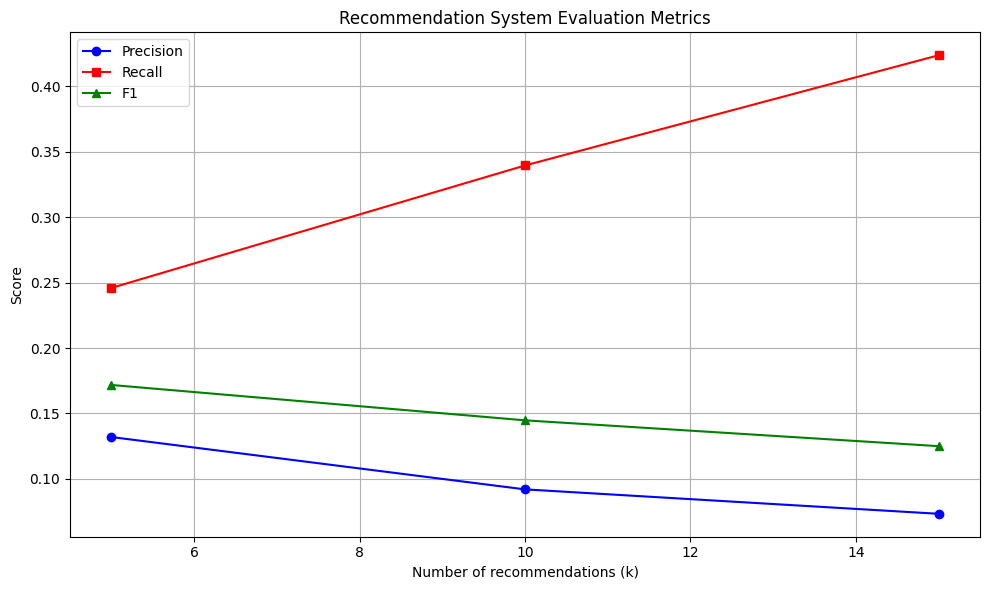

In [8]:
# Some more evaluation
# Evaluate for different values of k
import matplotlib.pyplot as plt
k_values = [5, 10, 15]
metrics = []

for k in k_values:
    result = evaluate_recommendations(interaction_matrix, item_similarity_df, k=k)
    metrics.append({
        'k': k,
        'precision': result['precision@k'],
        'recall': result['recall@k'],
        'f1': result['f1@k']
    })

# Convert to DataFrame for plotting

metrics_df = pd.DataFrame(metrics)

# Plot the metrics
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['k'], metrics_df['precision'], 'b-', marker='o', label='Precision')
plt.plot(metrics_df['k'], metrics_df['recall'], 'r-', marker='s', label='Recall')
plt.plot(metrics_df['k'], metrics_df['f1'], 'g-', marker='^', label='F1')
plt.xlabel('Number of recommendations (k)')
plt.ylabel('Score')
plt.title('Recommendation System Evaluation Metrics')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Evaluation with separate test data
We will evaluate the model using a separate test set. This will allow us to see how well the model generalizes to new data.

In [9]:
def evaluate_with_test_data(train_matrix, test_behaviors_path, item_similarity_df, k=10):
    """
    Evaluate the recommendation system using a separate test dataset.
    
    Args:
        train_matrix: The user-item interaction matrix used for training
        test_behaviors_path: Path to the test behaviors.tsv file
        item_similarity_df: Item-item similarity matrix from the training data
        k: Number of recommendations to generate for each user
        
    Returns:
        Dictionary with evaluation metrics
    """
    import numpy as np
    
    # Load the test behaviors file
    test_header = ['impression_id', 'user_id', 'time', 'history', 'impressions']
    test_df = pd.read_csv(test_behaviors_path, sep='\t', names=test_header)
    
    # Preprocess the test data similar to how the training data was processed
    test_df = test_df.drop_duplicates(subset='impression_id')
    test_df = test_df.drop_duplicates(subset=['user_id', 'time'])
    test_df = test_df.dropna()

    test_df['impressions'] = test_df['impressions'].apply(lambda x: [(i[:-2], int(i[-1])) for i in x.split()])
    test_df['history'] = test_df['history'].apply(lambda x: [i for i in x.split()])
    
    # Extract user-article interactions from test data
    user_ids = []
    article_ids = []
    click_values = []

    for _, row in test_df.iterrows():
        user = row['user_id']
        for impression in row['impressions']:
            article_id = impression[0]  # Extract the article ID
            click_value = impression[1]  # Extract the click value (0 or 1)
            user_ids.append(user)
            article_ids.append(article_id)
            click_values.append(click_value)

    # Create test interaction dataframe
    test_interaction_df = pd.DataFrame({
        'user_id': user_ids,
        'article_id': article_ids,
        'click': click_values
    })
    
    # Keep only the clicked articles (positive interactions)
    test_interaction_df = test_interaction_df[test_interaction_df['click'] > 0]
    
    # Group by user to get all articles clicked by each user
    test_user_clicks = test_interaction_df.groupby('user_id')['article_id'].apply(list).to_dict()
    
    # Find common users between train and test
    common_users = [user for user in test_user_clicks.keys() if user in train_matrix.index]

    # Randomize order of common users
    np.random.shuffle(common_users)
    #active_users = train_matrix.index[train_matrix.sum(axis=1) >= 5].tolist()
    
    # Initialize metrics
    precision_at_k = []
    recall_at_k = []
    
    # For each common user
    for user in common_users[:100]:
        user_interactions = train_matrix.loc[user]
        clicked_articles = user_interactions[user_interactions > 0].index.tolist()


        if len(clicked_articles) < 3:
            print(f"User {user} has too few interactions, skipping...")
            continue

        # Get test articles (ground truth)
        test_articles = test_user_clicks[user]

        # Create a modified interaction matrix for this user, hiding test items
        train_interactions = train_matrix.copy()
        for item in test_articles:
            train_interactions.loc[user, item] = 0
        
        # Get recommendations based on training data
        recs, _ = recommend_articles(user, train_interactions, item_similarity_df, n=k)
        print("recs for user", user, recs)
        
        # Calculate precision and recall
        n_relevant_and_recommended = len(set(recs) & set(test_articles))
        
        if len(recs) > 0:
            precision = n_relevant_and_recommended / len(recs)
            precision_at_k.append(precision)
        
        if len(test_articles) > 0:
            recall = n_relevant_and_recommended / len(test_articles)
            recall_at_k.append(recall)

        print(precision_at_k)
    
    # Calculate average metrics
    avg_precision = np.mean(precision_at_k) if precision_at_k else 0
    avg_recall = np.mean(recall_at_k) if recall_at_k else 0
    f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
    
    return {
        "precision@k": avg_precision,
        "recall@k": avg_recall,
        "f1@k": f1,
        "k": k,
        "users_evaluated": len(precision_at_k),
        "common_users_count": len(common_users)
    }

# Path to your test data file
test_behaviors_path = './test_behaviors.tsv'

# Run the evaluation using the separate test dataset
test_evaluation = evaluate_with_test_data(interaction_matrix, test_behaviors_path, item_similarity_df, k=10)
print(f"\nEvaluation results using separate test data for k={test_evaluation['k']} recommendations:")
print(f"Common users between train and test: {test_evaluation['common_users_count']}")
print(f"Number of users evaluated: {test_evaluation['users_evaluated']}")
print(f"Precision@{test_evaluation['k']}: {test_evaluation['precision@k']:.4f}")
print(f"Recall@{test_evaluation['k']}: {test_evaluation['recall@k']:.4f}")
print(f"F1@{test_evaluation['k']}: {test_evaluation['f1@k']:.4f}")

User U10311 has too few interactions, skipping...
recs for user U42289 ['N42977', 'N33885', 'N54489', 'N49685', 'N17059', 'N49279', 'N33619', 'N62360', 'N55689', 'N45738']
[0.0]
User U32412 has too few interactions, skipping...
recs for user U45915 ['N49180', 'N3123', 'N33619', 'N41020', 'N63970', 'N287', 'N53585', 'N42977', 'N42457', 'N26262']
[0.0, 0.0]
recs for user U69857 ['N35599', 'N47020', 'N30151', 'N26706', 'N49279', 'N3580', 'N49685', 'N7036', 'N64916', 'N247']
[0.0, 0.0, 0.0]
recs for user U73147 ['N62360', 'N38779', 'N23877', 'N287', 'N63970', 'N33619', 'N55689', 'N23446', 'N34185', 'N52122']
[0.0, 0.0, 0.0, 0.0]
recs for user U46745 ['N13556', 'N55689', 'N16547', 'N17858', 'N19618', 'N24347', 'N34315', 'N33619', 'N51048', 'N19661']
[0.0, 0.0, 0.0, 0.0, 0.0]
recs for user U59475 ['N33619', 'N62360', 'N63970', 'N53585', 'N45523', 'N3123', 'N287', 'N55689', 'N35729', 'N19592']
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
recs for user U71083 ['N37738', 'N7868', 'N35729', 'N63970', 'N53585'

We will modify the recommendation to take into account time decay. This means that the recommendations will be based on the most recent interactions, rather than all interactions. This is important because users' preferences may change over time, and we want to recommend items that are relevant to the user at the current time.

In [ ]:
def recommend_articles_with_time_decay(user_id, interaction_matrix, item_similarity_df, time_matrix, n=10):
    """
    Generate recommendations with time decay to prioritize recent interactions
    
    Args:
        user_id: The user to generate recommendations for
        interaction_matrix: The user-item interaction matrix
        item_similarity_df: Item-item similarity matrix
        time_matrix: Matrix with timestamps of user-item interactions
        n: Number of recommendations to generate
    """
    if user_id not in interaction_matrix.index:
        return [], {}
    
    user_interactions = interaction_matrix.loc[user_id]
    already_interacted = user_interactions[user_interactions > 0].index.tolist()
    
    # Get time information for this user's interactions
    user_times = time_matrix.loc[user_id]
    
    # Calculate time weights (more recent = higher weight)
    max_time = user_times.max()
    time_weights = {}
    for article in already_interacted:
        article_time = user_times[article]
        # Apply time decay function (e.g., linear, exponential)
        time_weight = 1 - (max_time - article_time) / max_time if max_time > 0 else 1
        time_weights[article] = max(0.1, time_weight)  # At least 0.1 weight
    
    # Calculate recommendation scores with time weighting
    recommendation_scores = pd.Series(0.0, index=interaction_matrix.columns)
    
    for article in already_interacted:
        similar_articles = item_similarity_df[article]
        # Weight by both interaction and time decay
        recommendation_scores += similar_articles * user_interactions[article] * time_weights[article]
    
    recommendation_scores = recommendation_scores.drop(already_interacted)
    top_recommendations = recommendation_scores.nlargest(n)
    
    return top_recommendations.index.tolist(), top_recommendations.to_dict()

Using 